--- Model Results ---
Accuracy: 99.97%
F1 Score: 0.9996

Detailed Classification Report:
              precision    recall  f1-score   support

   Blackhole       1.00      1.00      1.00      2526
      Normal       1.00      1.00      1.00      1132

    accuracy                           1.00      3658
   macro avg       1.00      1.00      1.00      3658
weighted avg       1.00      1.00      1.00      3658


Confusion Matrix saved as 'confusion_matrix.png'


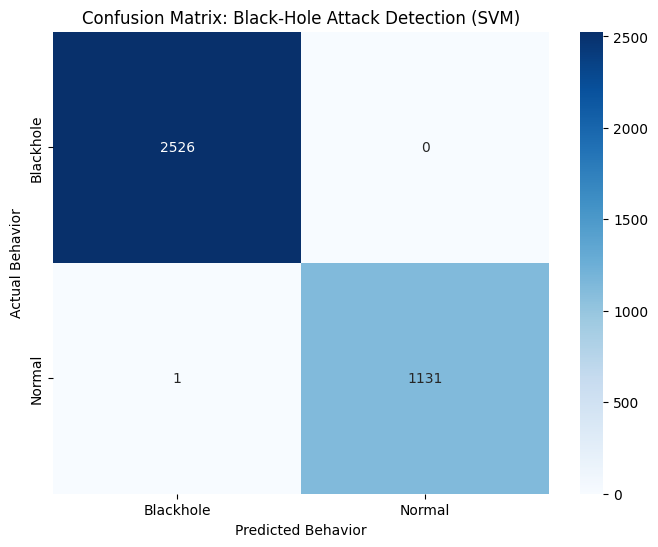

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# 1. Load the dataset
# Ensure 'UNR-IDD.csv' is in your working directory
df = pd.read_csv('UNR-IDD.csv')

# 2. Preprocessing
# Filter for 'Normal' and 'Blackhole' as per the base paper's specific focus
df_filtered = df[df['Label'].isin(['Normal', 'Blackhole'])].copy()

# Select feature columns (Behavioral metrics)
features = [
    'Received Packets', 'Received Bytes', 'Sent Bytes', 'Sent Packets',
    'Port alive Duration (S)', 'Packets Rx Dropped', 'Packets Tx Dropped',
    'Packets Rx Errors', 'Packets Tx Errors', 'Delta Received Packets',
    'Delta Received Bytes', 'Delta Sent Bytes', 'Delta Sent Packets',
    'Delta Port alive Duration (S)', 'Delta Packets Rx Dropped',
    ' Delta Packets Tx Dropped', 'Delta Packets Rx Errors',
    'Delta Packets Tx Errors', 'Total Load/Rate', 'Total Load/Latest',
    'Active Flow Entries'
]

X = df_filtered[features]
# Encode Target Labels: Blackhole = 0, Normal = 1
y = df_filtered['Label'].map({'Normal': 1, 'Blackhole': 0})

# 3. Data Splitting (70% Training, 30% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 4. Feature Scaling 
# SVM is highly sensitive to the scale of input data.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Build and Train the RBF SVM Model
# 'rbf' kernel is excellent for finding non-linear boundaries in network traffic.
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train_scaled, y_train)

# 6. Prediction
y_pred = svm_model.predict(X_test_scaled)

# 7. Evaluation
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"--- Model Results ---")
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"F1 Score: {f1:.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Blackhole', 'Normal']))

# 8. Visualization: Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Blackhole', 'Normal'], 
            yticklabels=['Blackhole', 'Normal'])
plt.title('Confusion Matrix: Black-Hole Attack Detection (SVM)')
plt.ylabel('Actual Behavior')
plt.xlabel('Predicted Behavior')
plt.savefig('confusion_matrix.png')
print("\nConfusion Matrix saved as 'confusion_matrix.png'")

In [2]:
import joblib

# Save the trained SVM model
joblib.dump(svm_model, 'blackhole_model.pkl')

# Save the scaler (so live data is scaled exactly like training data)
joblib.dump(scaler, 'scaler.pkl')

print("Files 'blackhole_model.pkl' and 'scaler.pkl' have been created!")

Files 'blackhole_model.pkl' and 'scaler.pkl' have been created!
